In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
c0 = 1.0
sigma_r = 1e-3
zr = np.array([-5.0, 0.0, 65.0])
N_sources = 200
n_receivers = 5

In [3]:
dw = 0.05
omegas = np.arange(-5, 5, dw)
sources = np.zeros((N_sources, 3))
sources[:, 0] = np.random.uniform(-50, 50, N_sources)   # x-coordinates
sources[:, 1] = np.random.uniform(-10, 10, N_sources)   # y-coordinates
sources[:, 2] = np.random.uniform(185, 200, N_sources)  # z-coordinates  a regarder
taus = np.linspace(-200, 200, 400)

In [9]:
n_receivers = 5
receivers = np.zeros((n_receivers, 3))

for j in range(n_receivers):
    # We use j because Python indexing starts at 0 
    # This corresponds exactly to (j-1) in the document's formula
    x_coord = -30 + 7.5 * j
    y_coord = 0
    z_coord = 100
    
    receivers[j] = np.array([x_coord, y_coord, z_coord])

# To access receiver x1 and x5 as requested in the first question:
x1 = receivers[0]
x5 = receivers[4]

In [4]:
def F(w):
    return np.exp(-w**2)

In [5]:
def G0(w,x,y):
    distance = np.linalg.norm(x-y)
    coefficient= 1/(4*np.pi*distance)
    exposant = 1j*w*distance/c0
    return coefficient*np.exp(exposant)

In [6]:
def G(w,x,y):
    G0_xy= G0(w,x,y)
    G0_xzr= G0(w,x,zr)
    G0_zry= G0(w,zr,y)
    return G0_xy + sigma_r*(w**2)*G0_xzr*G0_zry

In [13]:
def CN(tau,x1,x2):
    summ=0
    for s in range(N_sources):
        ys=sources[s]
        G_x1ys= G(omegas,x1,ys)
        G_x2ys= G(omegas,x2,ys)
        integrand=F(omegas)*np.conj(G_x1ys)*G_x2ys*np.exp(-1j*omegas*tau)
        integral=np.sum(integrand)*dw
        summ+=integral
    return summ/(2*np.pi*N_sources)

c:\Users\athee\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\athee\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


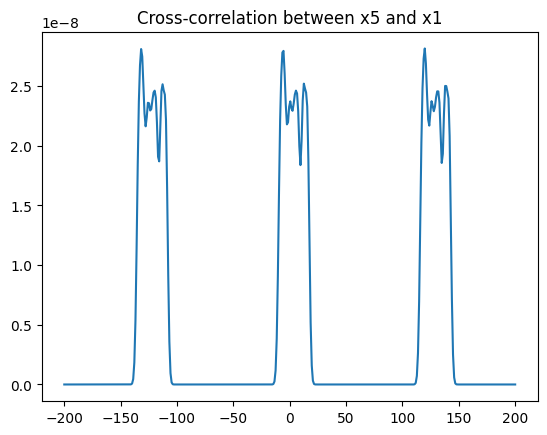

In [14]:
results = [CN(t, receivers[4], receivers[0]) for t in taus]
plt.plot(taus, results)
plt.title("Cross-correlation between x5 and x1")
plt.show()

In [15]:
def Km(ys):
    summ=0
    for j in range(n_receivers):
        for l in range(n_receivers):
            distance= np.linalg.norm(receivers[j]-ys)+np.linalg.norm(receivers[l]-ys)
            summ+=CN(distance, receivers[j], receivers[l])
    return summ

In [17]:
x_range = np.linspace(-15, 5, 50)  # 50 points for better resolution
z_range = np.linspace(55, 75, 50)
X, Z = np.meshgrid(x_range, z_range)
Intensity = np.zeros(X.shape)

# Fill the grid
for i in range(len(x_range)):
    for k in range(len(z_range)):
        search_point = np.array([x_range[i], 0, z_range[k]])
        Intensity[k, i] = Km(search_point)

# Plotting
plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Z, Intensity, shading='gouraud', cmap='hot')
plt.colorbar(label='Intensity')
plt.scatter(zr[0], zr[2], color='cyan', marker='x', label='True Reflector') # Mark true location
plt.xlabel('x')
plt.ylabel('z')
plt.title('Kirchhoff Migration (KM) Image')
plt.legend()
plt.show()

C:\Users\athee\AppData\Local\Temp\ipykernel_100744\2958116017.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  Intensity[k, i] = Km(search_point)


KeyboardInterrupt: 